# &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 2023-2024 NBA Playoffs Analysis

**Name:** Salman Limbada  
**Student ID:** 100921934

### Introduction:
The 2023-2024 NBA Playoffs provided an exciting display of basketball, where the best players in the world competed for the championship. For this analysis, I’m using a dataset from Kaggle that includes detailed statistics for NBA players throughout the playoffs. Since this is the playoffs this means that not all NBA players are included as only 16 teams play in the playoffs compared to the 30 total teams. The dataset has over 200 rows(the players) and 30 columns(the statistic categories), covering key stats like points per game (PTS), rebounds (TRB), assists (AST), field goal percentage (FG%), and minutes played (MP). With this data, there’s a lot of potential to uncover trends and insights about player performance in the playoffs.

One question I wanted to explore is how a player’s position (Pos) relates to their points per game (PTS) during the playoffs. Each position (Guard, Forward, and Center) has distinct responsibilities on the court. Guards are known for ball handling and outside shooting; Forwards focus on scoring and versatility across the court; and Centers specialize in rebounding, defending, and scoring in the paint. I’m interested in seeing if one position scores more points on average during the playoffs, or if scoring is spread across all positions.

Scoring is crucial in basketball, especially in the playoffs where every point is important. Understanding how different positions contribute to scoring can help us see which strategies might be most effective during this intense part of the season. For example, if Guards are the top scorers, it might show how important outside shooting is in today’s game. If Forwards score the most, it could highlight the value of versatile players who can contribute both inside and outside. Finally, if Centers dominate the scoring, it might emphasize the importance of inside play and offensive rebounding in the playoffs

By analyzing this, I hope to identify patterns in scoring and see how player positions impact playoff performance. These insights could help fans, coaches, and analysts better understand how teams use their players and what makes a successful playoff strategy.

![Mavericks vs Celtics in NBA Finals](https://images2.minutemediacdn.com/image/upload/c_crop,w_4350,h_2446,x_481,y_0/c_fill,w_1200,ar_16:9,f_auto,q_auto,g_auto/images/ImagnImages/mmsport/dallas_basketball/01j76tn514cwrdged18x.jpg)

**Image Source:** Peter Casey-Imagn Images - [Link to Original Image](https://www.si.com/nba/mavericks/news/dallas-mavericks-luka-doncic-made-boston-celtics-jayson-tatum-question-career-jeff-teague-evan-turner)

###  Data preperation
We first load the NBA dataset to begin our analysis.

In [1038]:
# import calls
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = "2023-2024 NBA Player Stats - Playoffs.csv"
nba_data = pd.read_csv(file_path ,delimiter =';')

We remove columns that aren't needed for this analysis of position and points scored, like defense and team info. We also rename some columns for clarity and readability.

In [1039]:
# Remove columns that aren't needed for this analysis
nba_data = nba_data.drop(columns=['Rk', 'GS', 'Age','STL', 'BLK', 'PF', 'TOV', '2PA', '3PA', '2P%', 'eFG%', 'DRB', 'TRB'])

# Rename columns to full names for clarity
nba_data.rename(columns={
    'Pos': 'Position',
    'PTS': 'Points',
    'AST': 'Assists',
    'FG%': 'Field Goal Percentage',
    'G': 'Games Played',
    'MP': 'Minutes Played',
    'FG': 'Field Goals Made',
    'FGA': 'Field Goals Attempted',
    'ORB': 'Offensive Rebounds',
    '3P':'3 Pointers Made' ,
    '3P%': '3 Point Percentage',
    '2P': '2 Pointers Made',
    'FT': 'Free throws made',
    'FTA': 'Free Throws Attempted',
	'FT%': 'Free throw Percentage',	
    'Tm': 'Team'
}, inplace=True)


As shown, there are no missing values across any of the players or stat categories.

In [1040]:
# check for null values in dataset
print("Missing values in each column:\n", nba_data.isnull().sum())

Missing values in each column:
 Player                   0
Position                 0
Team                     0
Games Played             0
Minutes Played           0
Field Goals Made         0
Field Goals Attempted    0
Field Goal Percentage    0
3 Pointers Made          0
3 Point Percentage       0
2 Pointers Made          0
Free throws made         0
Free Throws Attempted    0
Free throw Percentage    0
Offensive Rebounds       0
Assists                  0
Points                   0
dtype: int64


 But to keep the data clean, we include a step to remove any rows with missing values.

In [1041]:
# Drop rows with missing data if needed
nba_data = nba_data.dropna()

### Analyses

To explore how scoring varies by position, we calculate the average Points for each position. This helps identify which positions contribute the most to scoring on the offensive end. We will visualize this relationship using a bar chart. It reveals that Point guards score the most by position by a good margin. 

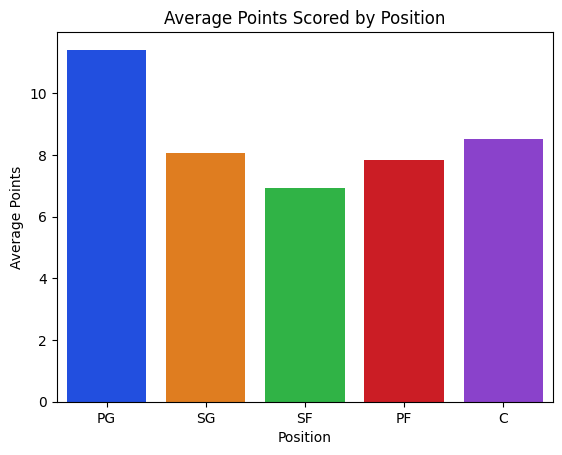

In [1042]:
# Define order of positions
position_order = ['PG', 'SG', 'SF', 'PF', 'C']

# Group by Position and calculate the average Points
avg_points_per_position = nba_data.groupby('Position')['Points'].mean().reindex(position_order)

# Create the bar plot with a title and y-axis label
sns.barplot(x=avg_points_per_position.index, y=avg_points_per_position.values, hue=avg_points_per_position.index, palette='bright', legend=False).set(title='Average Points Scored by Position')

# Add y-axis label
plt.ylabel('Average Points')

# Show the plot
plt.show()


For good understanding, Let's examine the total number of players that played in the playoffs for each position. Point guards have the lowest player count which could possibly impact why their point average was so High.

In [1043]:
# Count of players by position
position_count = nba_data['Position'].value_counts()
print(position_count)

Position
SF    47
PF    46
SG    42
C     41
PG    38
Name: count, dtype: int64


This section looks at Field Goal Percentage (FG%) which is a statistic to show how efficiently players score. Centers (C) have the highest FG%, as they take closer shots. Power Forwards (PF) have a wider range, shooting from both close and far. Shooting Guards (SG) are consistent but score less efficiently due to tougher, longer shots.

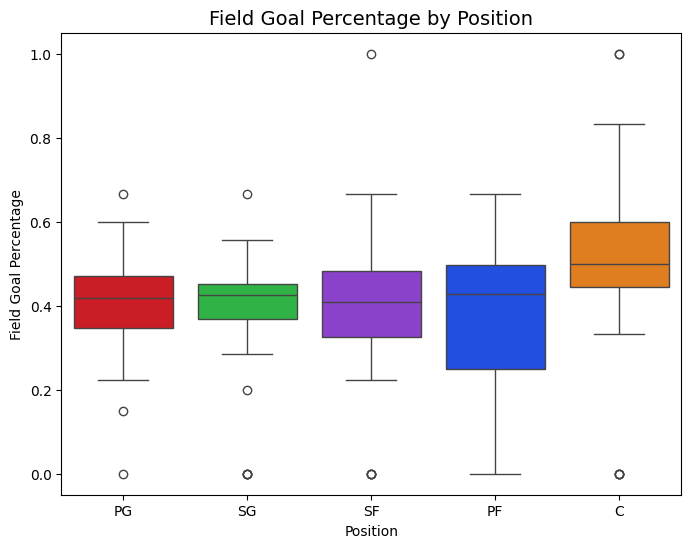

In [1044]:
# Visualizing Field Goal Percentage (FG%) by Position using a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=nba_data, x='Position', y='Field Goal Percentage', 
            order=['PG', 'SG', 'SF', 'PF', 'C'], hue='Position', palette='bright')

# Adding titles and labels
plt.title('Field Goal Percentage by Position', fontsize=14)

# Show the plot
plt.show()


#### Top 2 Finals team

This bar plot compares the average points scored by each position for players on the Mavericks and Celtics, the two teams that made it to the NBA Finals. The highest scoring player in the playoffs from these teams is Luka Dončić (PG) from the Mavericks. The Celtics’ star players, Jayson Tatum (PF) and Jaylen Brown (SG), raise the average for their positions. Meanwhile, the Mavericks’ Luka Dončić boosts their PG average, but Kyrie Irving (SG), who played poorly, drags the SG average down.

Highest scoring player in the playoffs that made the finals:

         Player Team Position  Points
42  Luka Doncic  DAL       PG    28.9 



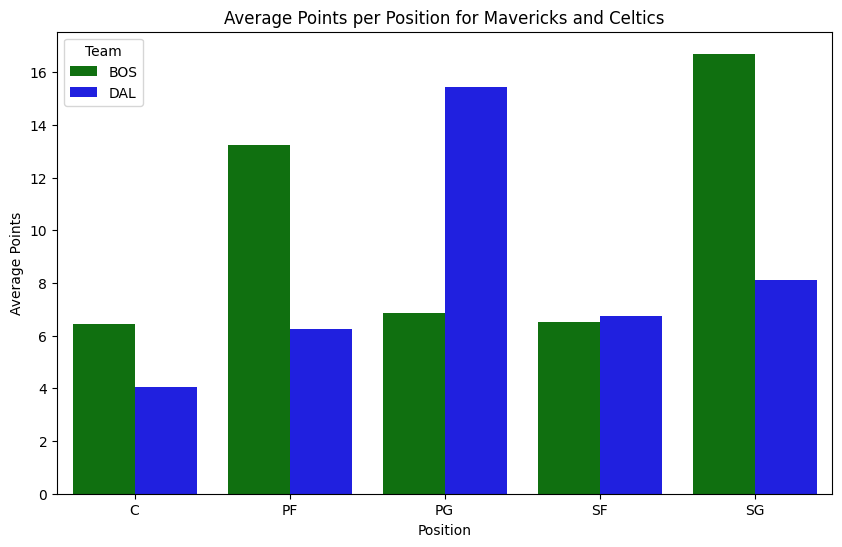

In [1045]:
# Filter data to include only Mavericks (DAL) and Celtics (BOS)
nba_filtered_teams = nba_data[nba_data['Team'].isin(['DAL', 'BOS'])]

# Find the highest scoring player across both teams
top_scorer = nba_filtered_teams.nlargest(1, 'Points')

# Print the highest scoring player
print("Highest scoring player in the playoffs that made the finals:\n")
print(top_scorer[['Player', 'Team', 'Position', 'Points']], "\n")

# Group by Team and Position, then calculate the average points for each group
avg_points_by_team_position = nba_filtered_teams.groupby(['Team', 'Position'])['Points'].mean().unstack(fill_value=0)

# Reset index to make 'Team' a column and prepare for the melting step
avg_points_by_team_position = avg_points_by_team_position.reset_index()

# Now melt the dataframe to reshape it for the bar plot
avg_points_melted = avg_points_by_team_position.melt(id_vars='Team', var_name='Position', value_name='Average Points')

# Create the grouped bar plot using seaborn with their jersey colors
plt.figure(figsize=(10, 6))
sns.barplot(x='Position', y='Average Points', hue='Team', data=avg_points_melted, palette={'DAL': 'blue', 'BOS': 'green'})

# Title 
plt.title('Average Points per Position for Mavericks and Celtics')

# Show the plot
plt.show()


#### Top 10 Scorers

Among the top 10 scorers, 6 are guards (PG and SG), highlighting the dominance of guards in scoring, with point guards making up 50% of the top 10.

In [1046]:
# Print top 10 scorers with their average points, excluding the index
top_10_scorers = nba_data.nlargest(10, 'Points')[['Player', 'Position', 'Points']]
print("\nHighest Scoring Players: Top 10 by Average Points\n")
print(top_10_scorers.to_string(index=False))

# Count number of Point Guards (PG) in the top 10
print(f"\nNumber of Point Guards (PG) in the top 10: {top_10_scorers[top_10_scorers['Position'] == 'PG'].shape[0]}")


Highest Scoring Players: Top 10 by Average Points

                 Player Position  Points
            Joel Embiid        C    33.0
          Jalen Brunson       PG    32.4
         Damian Lillard       PG    31.3
Shai Gilgeous-Alexander       PG    30.2
           Tyrese Maxey       PG    29.8
       Donovan Mitchell       SG    29.6
            Luka Doncic       PG    28.9
           Nikola Jokic        C    28.7
          Anthony Davis        C    27.8
           LeBron James       PF    27.8

Number of Point Guards (PG) in the top 10: 5


### What are some of the factors of why might Pointguards score the most?

The first factor we can look at is does the amount of time the point guards play impact their point average.

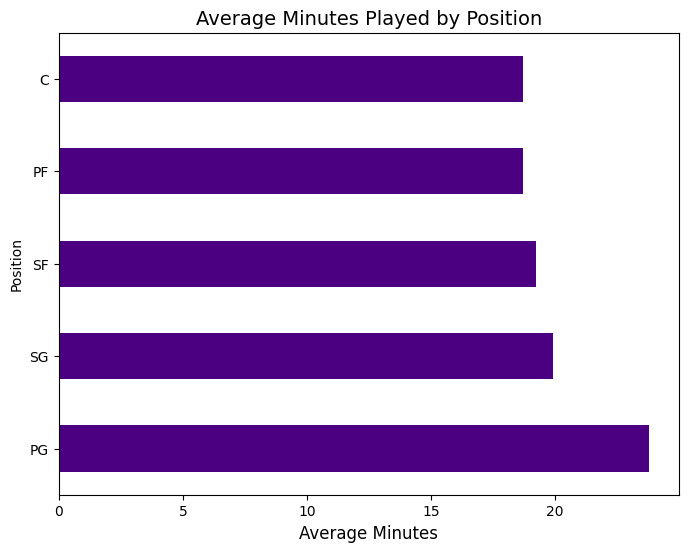

In [1047]:
avg_minutes_by_position = nba_data.groupby('Position')['Minutes Played'].mean().sort_values().reindex(position_order)
avg_minutes_by_position.plot(kind='barh', color='indigo', figsize=(8, 6))
plt.title('Average Minutes Played by Position', fontsize=14)
plt.xlabel('Average Minutes', fontsize=12)
plt.show()


As you can see, minutes played is probably a significant factor in how much they score.

#### Point Guards: Beyond Scoring
As a side note, let’s check if Point Guards are not only scoring but also contributing in other ways on offense, such as through 3-point shooting and assists.

In [1048]:
# Filter data for offensive stats comparison by position
offensive_stats = nba_data[['Position', '3 Pointers Made', 'Assists']]

# Group by Position and calculate the mean for 3-pointers and assists
offensive_comparison = offensive_stats.groupby('Position').mean()

# Display the comparison for Point Guards (PG) vs other positions
print(offensive_comparison.loc[['PG', 'SG', 'SF', 'PF', 'C']])

          3 Pointers Made   Assists
Position                           
PG               1.334211  3.392105
SG               1.221429  1.654762
SF               0.897872  1.287234
PF               0.734783  1.495652
C                0.463415  1.443902


While it's no surprise that they lead in assists due to their ball-handling role, it's interesting to see them also excelling in 3-point shooting—especially since there’s no Stephen Curry to inflate the numbers😅.

#### Free throws between positions
Let's explore whether Point Guards' higher free throw numbers contribute to them scoring the most.

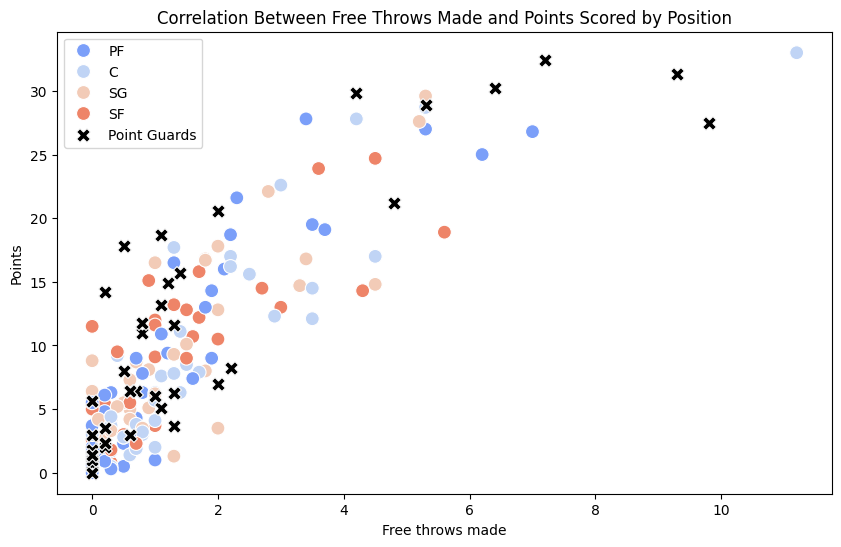

In [1049]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for relevant columns (Free Throws Made and Points)
offensive_stats = nba_data[['Position', 'Free throws made', 'Points']]

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=offensive_stats[offensive_stats['Position'] != 'PG'], 
                x='Free throws made', y='Points', hue='Position', palette='coolwarm', s=100)

# Highlight Point Guards (PG) with a different marker style
sns.scatterplot(data=offensive_stats[offensive_stats['Position'] == 'PG'], 
                x='Free throws made', y='Points', color='black', s=100, marker='X', label='Point Guards')

# Titles and labels
plt.title('Correlation Between Free Throws Made and Points Scored by Position')
plt.legend()

# Show the plot
plt.show()


After examining the scatter plot, we see that Point Guards (PGs) do indeed mostly score the most free throws, but other positions like Power Forwards (PF) and Centers (C) also contribute significantly. This suggests that while PGs benefit a lot from free throw attempts, other positions do just as much. This means free throws is probably not a factor in high scoring.

### Discussion
Our analysis examined the relationship between a player's position and their points scored during the playoffs. From the data, it is clear that Point Guards (PGs) are the highest scorers on average, likely due to their central role in controlling the ball and directing the offense. While PGs lead in points, other positions like Centers (C) and Power Forwards (PF) also play a significant role in scoring, especially through free throws, which highlights their aggressive playstyle in the paint.

Further analysis showed that PGs also lead in assists, as expected, given their playmaking role. Surprisingly, PGs also excel in 3-point shooting, despite the absence of historically high-volume shooters like Stephen Curry in the dataset. This indicates that PGs are not only key playmakers but also versatile scorers from beyond the arc.

Additionally, when comparing minutes played, PGs typically play the most minutes, reinforcing their pivotal role on the court. The data suggests that PGs’ higher scoring and playmaking abilities, combined with their extended time on the court, make them one of the most important contributors to a team’s offensive success.

In conclusion, while Point Guards clearly lead in scoring and assists, other positions like SG, PF, and C also make important contributions, particularly in free throws and physical play. This shows that a balanced offensive strategy involving multiple positions is crucial for playoff success. The interplay between scoring, playmaking, and minutes played highlights the importance of each position in the team’s overall performance, indicating that a strong, well-rounded offensive game is key to advancing in the playoffs.

### References
Dataset - https://www.kaggle.com/datasets/vivovinco/2023-2024-nba-player-stats/data

### LLM Prompts
• "how do i centre my title in jupyter notebook"

• "Could u make my introduction better"

• "the box plot shows up for me but also this, could u tell me what im missing:
py:3: FutureWarning: 

Passing palette without assigning hue is deprecated and will be removed in v0.14.0. Assign the x variable to hue and set legend=False for the same effect.

  sns.boxplot(data=nba_data, x='Position', y='Field Goal Percentage', order=['PG', 'SG', 'SF', 'PF', 'C'], palette="coolwarm")"

• "summarize this graph in a couple points for me to write about"

• "could u make my disussion better"

